In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn import hmm
import pyreadr

In [92]:
# input RDS data
rds_df = pyreadr.read_r("/Users/rainlam/Project/3.SV/localPCA/male_guppy_genome/MDS/YAH/YAH.LG6.win100.lostruct.windows.rds")
rds_df.values()

odict_values([           chrom       start         end     n         mid     mds01   
0     LR880650.1       154.0      2954.0     1      1554.0  0.210193  \
1     LR880650.1      2960.0      7671.0     2      5315.5  0.224611   
2     LR880650.1      7686.0     16217.0     3     11951.5  0.256329   
3     LR880650.1     16227.0     32914.0     4     24570.5  0.257069   
4     LR880650.1     33590.0     43566.0     5     38578.0  0.131874   
...          ...         ...         ...   ...         ...       ...   
4202  LR880650.1  32807972.0  32810005.0  4203  32808988.5 -0.076422   
4203  LR880650.1  32810009.0  32810953.0  4204  32810481.0 -0.075253   
4204  LR880650.1  32810973.0  32812094.0  4205  32811533.5 -0.024734   
4205  LR880650.1  32812096.0  32813096.0  4206  32812596.0  0.008027   
4206  LR880650.1  32813119.0  32822930.0  4207  32818024.5 -0.072001   

         mds02     mds03     mds04     mds05  ...     mds31     mds32   
0    -0.093180 -0.166132  0.087551 -0.379825  ..

In [93]:
for k,v in rds_df.items():
    df = v

In [94]:
subset_df = df.iloc[:,5:]
# data["gold_price_change"] = data["gold_price_usd"].diff()
df["mds02_diff"] = df["mds02"].diff()
df["mds01_diff"] = df["mds01"].diff()
df2= df[1:]

In [95]:
df[1:]

,chrom,start,end,n,mid,mds01,mds02,mds03,mds04,mds05,...,mds33,mds34,mds35,mds36,mds37,mds38,mds39,mds40,mds02_diff,mds01_diff
1,LR880650.1,2960.0,7671.0,2,5315.5,0.224611,-0.052542,-0.188806,0.029651,-0.359539,...,0.020778,-0.131283,0.059507,-0.059672,0.023277,-0.032682,0.008461,0.032255,0.040638,0.014418
2,LR880650.1,7686.0,16217.0,3,11951.5,0.256329,-0.085335,-0.238339,0.055245,-0.439954,...,-0.037672,-0.051504,-0.021362,-0.019955,0.010428,-0.051001,0.019830,-0.011512,-0.032793,0.031718
3,LR880650.1,16227.0,32914.0,4,24570.5,0.257069,-0.093654,-0.196310,0.091610,-0.426278,...,0.013032,-0.090510,-0.001491,-0.011499,-0.011503,-0.057714,0.032856,-0.011607,-0.008319,0.000740
4,LR880650.1,33590.0,43566.0,5,38578.0,0.131874,-0.057339,-0.110996,0.005388,-0.268066,...,0.052774,-0.076671,-0.033043,0.061886,-0.120745,-0.059816,-0.006260,0.052278,0.036315,-0.125195
5,LR880650.1,43596.0,57388.0,6,50492.0,0.209226,-0.069965,-0.157251,0.112656,-0.405272,...,0.014647,-0.080922,-0.005258,-0.004321,-0.038375,-0.057136,0.042426,0.005806,-0.012626,0.077352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4202,LR880650.1,32807972.0,32810005.0,4203,32808988.5,-0.076422,0.066794,0.034425,-0.002273,0.007999,...,-0.063564,-0.011720,-0.022864,-0.008320,-0.105900,0.017167,-0.047000,-0.039636,0.079648,-0.130175
4203,LR880650.1,32810009.0,32810953.0,4204,32810481.0,-0.075253,0.067905,0.068165,-0.047497,-0.068943,...,-0.059624,-0.083119,0.043001,-0.013827,-0.091187,0.050114,-0.116239,-0.021725,0.001112,0.001169
4204,LR880650.1,32810973.0,32812094.0,4205,32811533.5,-0.024734,0.063811,-0.015296,-0.024640,-0.069427,...,-0.077006,-0.058154,0.033126,0.037568,-0.059511,0.154879,-0.024196,0.019761,-0.004094,0.050519
4205,LR880650.1,32812096.0,32813096.0,4206,32812596.0,0.008027,0.088356,-0.024140,0.011477,-0.088663,...,-0.035501,-0.032978,0.042670,0.078849,-0.062309,0.102646,-0.050322,0.002053,0.024545,0.032761


In [96]:
# Use the daily change in gold price as the observed measurements X.
X = df2.iloc[:, 5:].values
# Build the HMM model and fit to the gold price change data.
model = hmm.GaussianHMM(n_components = 3, covariance_type = "diag", n_iter = 50, random_state = 42)
model.fit(X)
# Predict the hidden states corresponding to observed X.
Z = model.predict(X)
states = pd.unique(Z)

In [97]:
Z

array([1, 1, 1, ..., 2, 2, 2])

In [98]:
df2.iloc[:, 5:]

,mds01,mds02,mds03,mds04,mds05,mds06,mds07,mds08,mds09,mds10,...,mds33,mds34,mds35,mds36,mds37,mds38,mds39,mds40,mds02_diff,mds01_diff
1,0.224611,-0.052542,-0.188806,0.029651,-0.359539,0.049888,0.125199,-0.030728,0.049390,0.063198,...,0.020778,-0.131283,0.059507,-0.059672,0.023277,-0.032682,0.008461,0.032255,0.040638,0.014418
2,0.256329,-0.085335,-0.238339,0.055245,-0.439954,0.072123,0.106510,-0.064893,0.041992,-0.017806,...,-0.037672,-0.051504,-0.021362,-0.019955,0.010428,-0.051001,0.019830,-0.011512,-0.032793,0.031718
3,0.257069,-0.093654,-0.196310,0.091610,-0.426278,0.054955,0.111915,-0.027485,0.039781,-0.025859,...,0.013032,-0.090510,-0.001491,-0.011499,-0.011503,-0.057714,0.032856,-0.011607,-0.008319,0.000740
4,0.131874,-0.057339,-0.110996,0.005388,-0.268066,0.084066,0.084653,-0.078905,0.057760,0.013292,...,0.052774,-0.076671,-0.033043,0.061886,-0.120745,-0.059816,-0.006260,0.052278,0.036315,-0.125195
5,0.209226,-0.069965,-0.157251,0.112656,-0.405272,0.071594,0.136563,-0.039093,0.032370,-0.068577,...,0.014647,-0.080922,-0.005258,-0.004321,-0.038375,-0.057136,0.042426,0.005806,-0.012626,0.077352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4202,-0.076422,0.066794,0.034425,-0.002273,0.007999,0.097805,0.100553,-0.157072,-0.060318,0.149787,...,-0.063564,-0.011720,-0.022864,-0.008320,-0.105900,0.017167,-0.047000,-0.039636,0.079648,-0.130175
4203,-0.075253,0.067905,0.068165,-0.047497,-0.068943,-0.006853,0.036675,-0.007810,-0.054010,0.136489,...,-0.059624,-0.083119,0.043001,-0.013827,-0.091187,0.050114,-0.116239,-0.021725,0.001112,0.001169
4204,-0.024734,0.063811,-0.015296,-0.024640,-0.069427,0.072492,0.093394,-0.008550,-0.045989,0.031747,...,-0.077006,-0.058154,0.033126,0.037568,-0.059511,0.154879,-0.024196,0.019761,-0.004094,0.050519
4205,0.008027,0.088356,-0.024140,0.011477,-0.088663,0.073336,0.105944,0.011306,-0.068269,0.004783,...,-0.035501,-0.032978,0.042670,0.078849,-0.062309,0.102646,-0.050322,0.002053,0.024545,0.032761


In [99]:
df2.iloc[:,1:]

,start,end,n,mid,mds01,mds02,mds03,mds04,mds05,mds06,...,mds33,mds34,mds35,mds36,mds37,mds38,mds39,mds40,mds02_diff,mds01_diff
1,2960.0,7671.0,2,5315.5,0.224611,-0.052542,-0.188806,0.029651,-0.359539,0.049888,...,0.020778,-0.131283,0.059507,-0.059672,0.023277,-0.032682,0.008461,0.032255,0.040638,0.014418
2,7686.0,16217.0,3,11951.5,0.256329,-0.085335,-0.238339,0.055245,-0.439954,0.072123,...,-0.037672,-0.051504,-0.021362,-0.019955,0.010428,-0.051001,0.019830,-0.011512,-0.032793,0.031718
3,16227.0,32914.0,4,24570.5,0.257069,-0.093654,-0.196310,0.091610,-0.426278,0.054955,...,0.013032,-0.090510,-0.001491,-0.011499,-0.011503,-0.057714,0.032856,-0.011607,-0.008319,0.000740
4,33590.0,43566.0,5,38578.0,0.131874,-0.057339,-0.110996,0.005388,-0.268066,0.084066,...,0.052774,-0.076671,-0.033043,0.061886,-0.120745,-0.059816,-0.006260,0.052278,0.036315,-0.125195
5,43596.0,57388.0,6,50492.0,0.209226,-0.069965,-0.157251,0.112656,-0.405272,0.071594,...,0.014647,-0.080922,-0.005258,-0.004321,-0.038375,-0.057136,0.042426,0.005806,-0.012626,0.077352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4202,32807972.0,32810005.0,4203,32808988.5,-0.076422,0.066794,0.034425,-0.002273,0.007999,0.097805,...,-0.063564,-0.011720,-0.022864,-0.008320,-0.105900,0.017167,-0.047000,-0.039636,0.079648,-0.130175
4203,32810009.0,32810953.0,4204,32810481.0,-0.075253,0.067905,0.068165,-0.047497,-0.068943,-0.006853,...,-0.059624,-0.083119,0.043001,-0.013827,-0.091187,0.050114,-0.116239,-0.021725,0.001112,0.001169
4204,32810973.0,32812094.0,4205,32811533.5,-0.024734,0.063811,-0.015296,-0.024640,-0.069427,0.072492,...,-0.077006,-0.058154,0.033126,0.037568,-0.059511,0.154879,-0.024196,0.019761,-0.004094,0.050519
4205,32812096.0,32813096.0,4206,32812596.0,0.008027,0.088356,-0.024140,0.011477,-0.088663,0.073336,...,-0.035501,-0.032978,0.042670,0.078849,-0.062309,0.102646,-0.050322,0.002053,0.024545,0.032761


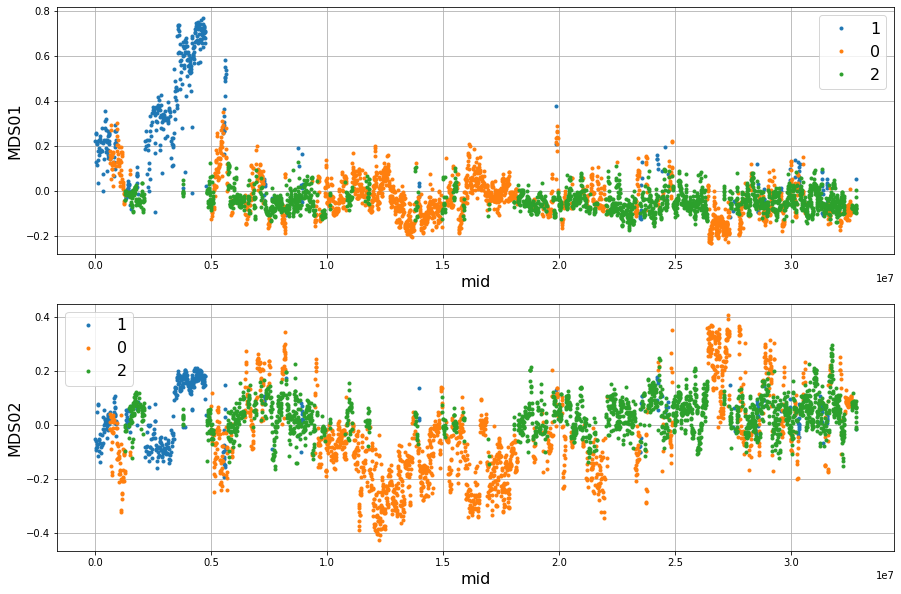

In [100]:
plt.figure(figsize = (15, 10))
plt.subplot(2,1,1)
for i in states:
    want = (Z == i)
    x = df2["mid"].iloc[want]
    y = df2["mds01"].iloc[want]
    plt.plot(x, y, '.')
plt.legend(states, fontsize=16)
plt.grid(True)
plt.xlabel("mid", fontsize=16)
plt.ylabel("MDS01", fontsize=16)
plt.subplot(2,1,2)
for i in states:
    want = (Z == i)
    x = df2["mid"].iloc[want]
    y = df2["mds02"].iloc[want]
    plt.plot(x, y, '.')
plt.legend(states, fontsize=16)
plt.grid(True)
plt.xlabel("mid", fontsize=16)
plt.ylabel("MDS02", fontsize=16)
plt.show()

In [132]:
# Find the indices of consecutive 2s
consecutive_twos = np.where((Z[:-1] == 1) & (Z[1:] == 1))[0]

rows_corresponding_to_twos = df.iloc[consecutive_twos]
rows_corresponding_to_twos 
df.iloc[235:465]["mid"]

235    2125362.0
236    2149752.0
237    2169613.5
238    2196855.5
239    2218779.0
         ...    
460    4704403.5
461    4713510.5
462    4722880.0
463    4731913.5
464    4743666.5
Name: mid, Length: 230, dtype: float64

In [130]:
from itertools import groupby

# Find the indices of consecutive 2s
consecutive_twos = np.where((Z[:-1] == 1) & (Z[1:] == 1))[0]

rows_corresponding_to_twos = df.iloc[consecutive_twos]

lst = rows_corresponding_to_twos['n']

result = []
for k, g in groupby(enumerate(lst), lambda x: x[0] - x[1]):
    consecutive = list(map(lambda x: x[1], g))
    result.append(consecutive)

# 输出连续的整数序列
for sequence in result:
    print(sequence)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
[75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87]
[136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151]
[162, 163]
[199, 200, 201, 202, 203, 204, 205]
[235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348]
[358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 3

In [126]:
rows_corresponding_to_twos

,chrom,start,end,n,mid,mds01,mds02,mds03,mds04,mds05,...,mds33,mds34,mds35,mds36,mds37,mds38,mds39,mds40,mds02_diff,mds01_diff
0,LR880650.1,154.0,2954.0,1,1554.0,0.210193,-0.093180,-0.166132,0.087551,-0.379825,...,-0.044945,-0.014540,0.061730,-0.037878,0.006144,-0.058769,0.040036,0.007089,NaN,NaN
1,LR880650.1,2960.0,7671.0,2,5315.5,0.224611,-0.052542,-0.188806,0.029651,-0.359539,...,0.020778,-0.131283,0.059507,-0.059672,0.023277,-0.032682,0.008461,0.032255,0.040638,0.014418
2,LR880650.1,7686.0,16217.0,3,11951.5,0.256329,-0.085335,-0.238339,0.055245,-0.439954,...,-0.037672,-0.051504,-0.021362,-0.019955,0.010428,-0.051001,0.019830,-0.011512,-0.032793,0.031718
3,LR880650.1,16227.0,32914.0,4,24570.5,0.257069,-0.093654,-0.196310,0.091610,-0.426278,...,0.013032,-0.090510,-0.001491,-0.011499,-0.011503,-0.057714,0.032856,-0.011607,-0.008319,0.000740
4,LR880650.1,33590.0,43566.0,5,38578.0,0.131874,-0.057339,-0.110996,0.005388,-0.268066,...,0.052774,-0.076671,-0.033043,0.061886,-0.120745,-0.059816,-0.006260,0.052278,0.036315,-0.125195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3989,LR880650.1,31529714.0,31536648.0,3990,31533181.0,-0.033569,0.013668,0.000920,-0.025725,0.003957,...,0.143749,-0.003760,-0.060373,0.142252,0.024382,0.033608,-0.057624,0.017459,-0.033065,0.023915
3990,LR880650.1,31536749.0,31542046.0,3991,31539397.5,0.056031,0.006167,0.015344,-0.026378,-0.079654,...,0.106575,-0.009147,-0.064863,0.077281,-0.056099,0.022444,-0.101753,-0.000452,-0.007501,0.089600
3991,LR880650.1,31542048.0,31548636.0,3992,31545342.0,0.036799,0.018446,0.009947,-0.025518,-0.087591,...,0.115347,-0.022909,-0.078874,0.090843,-0.025958,0.038498,-0.105354,0.009255,0.012279,-0.019232
3992,LR880650.1,31548742.0,31555397.0,3993,31552069.5,0.027602,0.024218,0.012524,-0.031298,-0.083703,...,0.116916,-0.044205,-0.095310,0.100366,-0.043291,0.042397,-0.110395,0.018027,0.005772,-0.009197


In [117]:
for i in rows_corresponding_to_twos['mid']:
    print(i)


1554.0
5315.5
11951.5
24570.5
38578.0
50492.0
69696.0
88122.5
95899.5
99525.0
111226.5
124953.0
137559.0
154290.0
168313.0
185947.5
203066.0
219789.0
240912.0
257757.5
275339.0
295754.5
311653.0
322921.5
340623.0
362403.0
375573.5
385048.0
399072.5
413325.0
427142.0
438109.0
446456.0
455583.5
464711.0
473626.0
483051.0
491952.5
500688.0
509553.0
519318.5
527792.0
536534.5
545401.5
551165.5
556839.5
564710.0
572739.0
582361.5
591899.5
598146.5
801723.0
809143.0
816597.0
823137.0
828647.5
834946.0
842622.5
849501.5
854828.5
860707.0
867703.0
876825.5
885644.5
1313974.5
1323117.5
1330045.0
1336041.5
1342538.5
1349548.0
1356565.5
1364352.0
1372002.5
1378150.0
1384431.0
1392967.5
1401826.5
1409243.5
1416165.5
1423031.5
1503777.0
1510147.0
1777223.0
1783276.5
1786781.0
1788761.5
1792820.0
1798539.5
1804063.5
2103886.5
2125362.0
2149752.0
2169613.5
2196855.5
2218779.0
2235099.5
2251837.5
2272168.5
2283875.5
2292626.0
2301203.5
2306045.0
2319837.0
2342517.0
2360746.5
2376557.5
2398318.5
241376